# 의료 접근성이 건강 결과에 미치는 영향 분석

BRFSS 2015 당뇨병 건강지표 데이터셋을 이용해 의료 접근성(`AnyHealthcare`, `NoDocbcCost`, `CholCheck`)이 건강 결과(`Diabetes_binary`, `GenHlth`, `PhysHlth`, `HighBP`, `HighChol`)에 미치는 영향을 분석한다.

소득(`Income`), 연령(`Age`), 교육수준(`Education`)을 교란변수로 통제하여 접근성 변수의 독립적 효과를 추정하는 것이 핵심 질문이다.

**진행 순서**: 데이터 전처리 → EDA → 교란변수 선정 → 기초 모델링(로지스틱 회귀) → 예측 모델링 → 인사이트 정리

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import statsmodels.api as sm
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

DATA_PATH = "../data/raw/diabetes_binary_health_indicators_BRFSS2015.csv"
df = pd.read_csv(DATA_PATH)
df.shape

(253680, 22)

## 1. 데이터 전처리

결측치, 중복행, 값 범위(코드북 대비 이상값)를 확인하고 분석에 쓸 변수들의 타입을 정리한다.

In [2]:
# 결측치 / 중복행 확인
print("Missing values total:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
df.info()

Missing values total: 0
Duplicate rows: 24206
<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth          

In [3]:
# 코드북 대비 값 범위 점검 (모든 컬럼이 float이지만 실제로는 이진/순서형 코드)
for col in ["AnyHealthcare", "NoDocbcCost", "CholCheck", "Diabetes_binary"]:
    print(col, sorted(df[col].unique()))
for col in ["Income", "Education", "GenHlth", "Age"]:
    print(col, sorted(df[col].unique()))

AnyHealthcare [np.float64(0.0), np.float64(1.0)]
NoDocbcCost [np.float64(0.0), np.float64(1.0)]
CholCheck [np.float64(0.0), np.float64(1.0)]
Diabetes_binary [np.float64(0.0), np.float64(1.0)]
Income [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0)]
Education [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0)]
GenHlth [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]
Age [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0)]


**중복행 처리 방침**: 전체 253,680행 중 24,206행(9.5%)이 완전히 동일한 값 조합을 가진다. 모든 변수가 구간화된 범주형 코드이고 표본 크기가 크기 때문에, 서로 다른 응답자가 우연히 같은 코드 조합을 가질 가능성이 충분히 있다(데이터 입력 오류로 보기 어려움). 따라서 이번 분석에서는 중복행을 삭제하지 않고 전체 표본을 유지한다 — 다만 리포트의 한계(limitation)로 명시한다.

모든 이진/순서형 변수의 값 범위는 코드북과 일치함을 확인했다 (`AnyHealthcare`, `NoDocbcCost`, `CholCheck`, `Diabetes_binary` ∈ {0,1}, `Income` 1~8, `Education` 1~6, `GenHlth` 1~5, `Age` 1~13 구간코드).

In [4]:
# 해석 편의를 위한 라벨 매핑 (BRFSS 2015 코드북 기준)
age_labels = {1: "18-24", 2: "25-29", 3: "30-34", 4: "35-39", 5: "40-44", 6: "45-49",
              7: "50-54", 8: "55-59", 9: "60-64", 10: "65-69", 11: "70-74", 12: "75-79", 13: "80+"}
income_labels = {1: "<10k", 2: "10-15k", 3: "15-20k", 4: "20-25k", 5: "25-35k",
                 6: "35-50k", 7: "50-75k", 8: "75k+"}
genhlth_labels = {1: "Excellent", 2: "Very good", 3: "Good", 4: "Fair", 5: "Poor"}

df_eda = df.copy()
df_eda["AgeGroup"] = df_eda["Age"].map(age_labels)
df_eda["IncomeGroup"] = df_eda["Income"].map(income_labels)
df_eda["GenHlthLabel"] = df_eda["GenHlth"].map(genhlth_labels)
df_eda["PoorGenHlth"] = (df_eda["GenHlth"] >= 4).astype(int)  # Fair/Poor = 1
df_eda.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,PhysHlth,DiffWalk,Sex,Age,Education,Income,AgeGroup,IncomeGroup,GenHlthLabel,PoorGenHlth
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,15.0,1.0,0.0,9.0,4.0,3.0,60-64,15-20k,Poor,1
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,7.0,6.0,1.0,50-54,<10k,Good,0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,30.0,1.0,0.0,9.0,4.0,8.0,60-64,75k+,Poor,1
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,11.0,3.0,6.0,70-74,35-50k,Very good,0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,11.0,5.0,4.0,70-74,20-25k,Very good,0


## 2. EDA - 의료 접근성 변수 분포

`AnyHealthcare`(보험/의료이용 가능 여부), `NoDocbcCost`(비용 때문에 병원 미방문 경험), `CholCheck`(5년 내 콜레스테롤 검사 여부)의 분포를 확인한다.

--- AnyHealthcare ---
AnyHealthcare
0.0    0.048947
1.0    0.951053
Name: proportion, dtype: float64

--- NoDocbcCost ---
NoDocbcCost
0.0    0.915823
1.0    0.084177
Name: proportion, dtype: float64

--- CholCheck ---
CholCheck
0.0    0.03733
1.0    0.96267
Name: proportion, dtype: float64



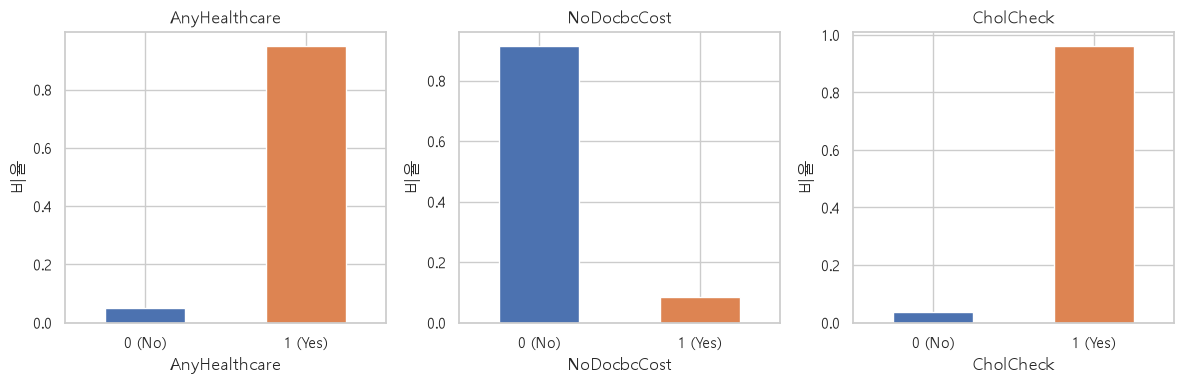

In [5]:
access_vars = ["AnyHealthcare", "NoDocbcCost", "CholCheck"]
for col in access_vars:
    print(f"--- {col} ---")
    print(df_eda[col].value_counts(normalize=True).sort_index())
    print()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axes, access_vars):
    df_eda[col].value_counts(normalize=True).sort_index().plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
    ax.set_title(col)
    ax.set_ylabel("비율")
    ax.set_xticklabels(["0 (No)", "1 (Yes)"], rotation=0)
plt.tight_layout()
plt.show()

**시사점**: 세 접근성 지표 모두 대부분 "예(접근성 있음)" 쪽에 크게 치우친 분포다 — `AnyHealthcare` 95.1%, `CholCheck` 96.3%가 Yes이고, `NoDocbcCost`는 반대로 91.6%가 "No"(비용장벽 없음)다. 즉 분석 대상은 사실상 **소수의 취약집단**(의료 미보유 4.9%, 비용장벽 경험 8.4%, 미검진 3.7%)이며, 이들이 다수 집단과 결과에서 얼마나 다른지가 핵심 질문이 된다. 표본이 불균형하므로 이후 비율 차이는 절대적 크기보다 방향과 통계적 유의성 중심으로 해석해야 한다.

## 3. 접근성 변수 vs 건강 결과: 교차분석 및 카이제곱검정

각 접근성 변수와 결과지표(`Diabetes_binary`, `PoorGenHlth`, `HighBP`, `HighChol`) 간 비율 차이와 통계적 유의성을 확인한다.

In [6]:
outcome_vars = ["Diabetes_binary", "PoorGenHlth", "HighBP", "HighChol"]

results = []
for a in access_vars:
    for o in outcome_vars:
        ct = pd.crosstab(df_eda[a], df_eda[o])
        chi2, p, dof, exp = chi2_contingency(ct)
        rate0 = df_eda.loc[df_eda[a] == 0, o].mean()
        rate1 = df_eda.loc[df_eda[a] == 1, o].mean()
        results.append({
            "access_var": a, "outcome": o,
            "rate_when_0": round(rate0, 4), "rate_when_1": round(rate1, 4),
            "diff": round(rate1 - rate0, 4), "chi2_p": p
        })

results_df = pd.DataFrame(results)
results_df

,access_var,outcome,rate_when_0,rate_when_1,diff,chi2_p
0,AnyHealthcare,Diabetes_binary,0.1145,0.1406,0.0261,2.986181e-16
1,AnyHealthcare,PoorGenHlth,0.2284,0.1692,-0.0592,4.203328e-65
2,AnyHealthcare,HighBP,0.3452,0.4333,0.0881,2.291157e-83
3,AnyHealthcare,HighChol,0.3321,0.4289,0.0967,2.638219e-100
4,NoDocbcCost,Diabetes_binary,0.1360,0.1752,0.0392,2.218395e-56
5,NoDocbcCost,PoorGenHlth,0.1546,0.3625,0.2079,0.000000e+00
6,NoDocbcCost,HighBP,0.4264,0.4573,0.0309,2.427700e-18
7,NoDocbcCost,HighChol,0.4221,0.4458,0.0237,2.132523e-11
8,CholCheck,Diabetes_binary,0.0254,0.1437,0.1183,3.751399e-233
9,CholCheck,PoorGenHlth,0.1060,0.1746,0.0686,2.226386e-67


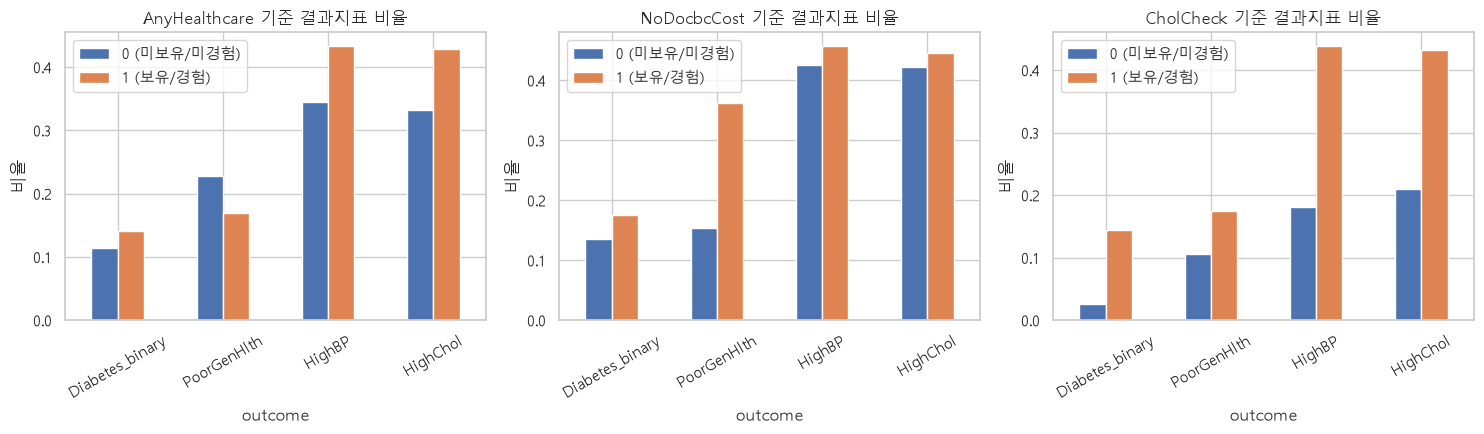

In [7]:
fig, axes = plt.subplots(1, len(access_vars), figsize=(15, 4.5), sharey=False)
for ax, a in zip(axes, access_vars):
    sub = results_df[results_df["access_var"] == a].set_index("outcome")[["rate_when_0", "rate_when_1"]]
    sub.plot(kind="bar", ax=ax)
    ax.set_title(f"{a} 기준 결과지표 비율")
    ax.set_ylabel("비율")
    ax.legend(["0 (미보유/미경험)", "1 (보유/경험)"])
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

**시사점**: 세 접근성 변수 모두 카이제곱검정에서 모든 결과지표와 통계적으로 유의한 연관을 보인다(전부 p<0.001). 방향은 대체로 "접근성 문제가 있을수록 결과가 나쁘다"와 일치하지만 예외가 있다 — `AnyHealthcare`는 `Diabetes_binary`에서 오히려 보험 보유군의 유병률이 더 높고(11.5%→14.1%), `CholCheck`는 당뇨 비율 차이가 극단적으로 크다(2.5%→14.4%, +11.8%p). 이는 개선이 아니라 **검출편향** — 검진·의료 이용을 해야 진단이 기록되는 구조 — 일 가능성이 높다. 반면 `NoDocbcCost`는 `PoorGenHlth`에서 15.5%→36.3%(+20.8%p)로 가장 크고 방향이 일관된 차이를 보여, 뒤의 모델링에서 더 신뢰할 수 있는 신호로 다뤄야 한다.

## 4. 교란변수 선정

로지스틱 회귀에서 어떤 변수를 교란변수(통제변수)로 넣을지는 "조정 후 오즈비가 얼마나 바뀌었는가"로 사후에 정하는 게 아니라, **노출(접근성)과 결과(당뇨) 양쪽에 모두 연관된 변수인가**를 기준으로 사전에 정해야 한다. 아래 3단계로 후보를 스크리닝한다.

1. 도메인 지식으로 후보 나열 (`Income`, `Age`, `Education`, `Sex`, `BMI`, `Smoker`, `PhysActivity`)
2. 접근성 변수·결과변수 양쪽과의 상관관계를 확인해, 두 조건을 동시에 만족하는지 통계적으로 스크리닝
3. 통계만으로는 판단할 수 없는 매개변수(mediator) 가능성을 논리적으로 재검토

In [8]:
candidates = ["Income", "Age", "Education", "Sex", "BMI", "Smoker", "PhysActivity"]

screen = pd.DataFrame(index=candidates)
for a in access_vars:
    screen[a] = [df_eda[c].corr(df_eda[a]) for c in candidates]
screen["Diabetes_binary"] = [df_eda[c].corr(df_eda["Diabetes_binary"]) for c in candidates]
screen.round(3)

,AnyHealthcare,NoDocbcCost,CholCheck,Diabetes_binary
Income,0.158,-0.203,0.014,-0.164
Age,0.138,-0.120,0.090,0.177
Education,0.123,-0.101,0.002,-0.124
Sex,-0.019,-0.045,-0.022,0.031
BMI,-0.018,0.058,0.034,0.217
Smoker,-0.023,0.049,-0.010,0.061
PhysActivity,0.036,-0.062,0.004,-0.118


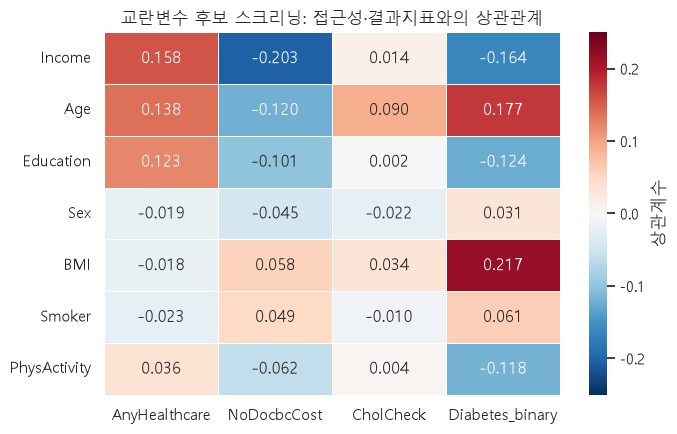

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.heatmap(screen.astype(float), annot=True, fmt=".3f", cmap="RdBu_r", center=0,
            vmin=-0.25, vmax=0.25, linewidths=0.6, linecolor="white",
            cbar_kws={"label": "상관계수"}, ax=ax)
ax.set_title("교란변수 후보 스크리닝: 접근성·결과지표와의 상관관계")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

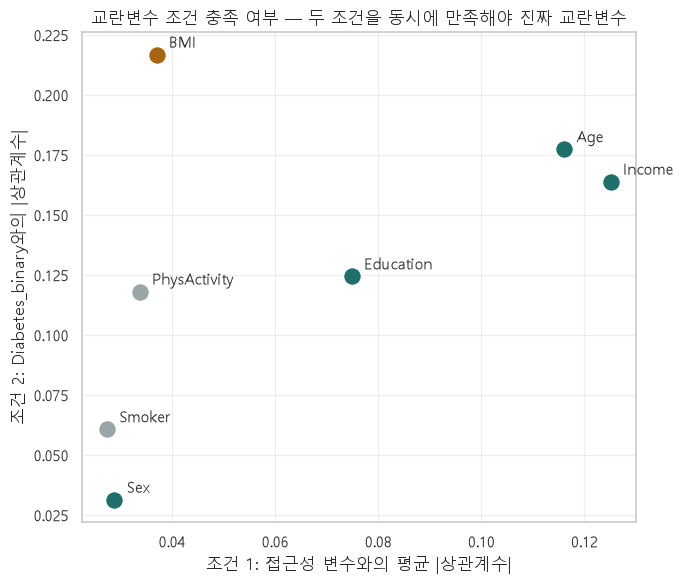

In [10]:
# 조건 1: 접근성 변수들과의 평균 |상관관계| / 조건 2: 결과(Diabetes_binary)와의 |상관관계|
screen["access_strength"] = screen[access_vars].abs().mean(axis=1)
screen["outcome_strength"] = screen["Diabetes_binary"].abs()

fig, ax = plt.subplots(figsize=(7, 6))
colors = {"Income": "#1F6F6B", "Age": "#1F6F6B", "Education": "#1F6F6B", "Sex": "#1F6F6B",
          "BMI": "#A6660F", "Smoker": "#9AA5A8", "PhysActivity": "#9AA5A8"}
for c in candidates:
    x, y = screen.loc[c, "access_strength"], screen.loc[c, "outcome_strength"]
    ax.scatter(x, y, s=170, color=colors[c], edgecolor="white", linewidth=1.2, zorder=3)
    ax.annotate(c, (x, y), textcoords="offset points", xytext=(9, 5), fontsize=10.5)
ax.set_xlabel("조건 1: 접근성 변수와의 평균 |상관계수|")
ax.set_ylabel("조건 2: Diabetes_binary와의 |상관계수|")
ax.set_title("교란변수 조건 충족 여부 — 두 조건을 동시에 만족해야 진짜 교란변수")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**시사점**: 산점도에서 `Income`(0.125·0.164)과 `Age`(0.116·0.177)는 x축(접근성 연관)과 y축(결과 연관) 모두 상위권에 위치해 교란변수의 두 조건을 동시에 만족한다 — 가장 확실한 교란변수 후보다. `Education`(0.075·0.124)도 두 축 모두 준수해 교란변수로 채택할 만하다. 반면 `BMI`는 y축에서 전체 후보 중 가장 높은 값(0.217)을 보이지만 x축은 가장 낮은 축에 속해(0.037) 그래프 왼쪽 위 구석에 혼자 떨어져 있다 — 결과와는 강하게 연관되지만 접근성과는 거의 무관하다는 뜻으로, 교란변수 조건 중 절반만 만족한다. `Smoker`, `Sex`, `PhysActivity`는 두 축 모두 낮아 왼쪽 아래에 뭉쳐 있어 교란변수로 채택할 통계적 근거가 약하다.

두 조건을 곱한 종합 점수로 순위를 매기면 `Age`(0.0206) ≈ `Income`(0.0205) > `Education`(0.0093) > `BMI`(0.0080) 순인데, 이 점수는 두 축을 하나로 뭉개기 때문에 `BMI`처럼 한쪽만 극단적인 경우를 과소평가할 수 있다 — 그래서 점수 하나보다는 산점도로 두 조건을 따로 보는 게 더 정확하다.

**3단계 — 매개변수 여부 재검토**: 산점도까지는 상관관계로 확인할 수 있지만, "이 변수가 접근성의 원인 쪽인지, 접근성 때문에 생기는 결과(매개변수)인지"는 통계만으로 구분할 수 없고 논리적 판단이 필요하다.

- `Income`, `Age`, `Education`, `Sex`: 접근성이 이 값들을 바꿀 수는 없다 — 오히려 소득이 낮아서 접근성이 떨어지는 것이므로 방향이 명확한 안전한 교란변수다.
- `BMI`: "접근성이 없어서 예방관리를 못 받아 BMI가 올라갔다"는 반대 방향 인과도 성립할 수 있어, 매개변수일 가능성을 배제할 수 없다 — 통제변수로는 넣되 해석에 유의해야 한다.

**최종 선정**: `Income`, `Age`, `Education`, `Sex`를 핵심 교란변수로, `BMI`는 매개변수 가능성이 있는 강한 독립 위험요인으로 구분해 이후 모델에 함께 포함한다.

## 5. 교란변수(소득) 심층 층화분석

앞선 스크리닝에서 `Income`이 가장 확실한 교란변수 후보로 확인됐다. 소득 구간별로 접근성 변수와 결과지표가 어떻게 같이 움직이는지 좀 더 자세히 들여다본다.

In [11]:
income_order = [income_labels[i] for i in range(1, 9)]

income_summary = df_eda.groupby("IncomeGroup").agg(
    NoDocbcCost_rate=("NoDocbcCost", "mean"),
    AnyHealthcare_rate=("AnyHealthcare", "mean"),
    Diabetes_rate=("Diabetes_binary", "mean"),
    PoorGenHlth_rate=("PoorGenHlth", "mean"),
).reindex(income_order)
income_summary

,NoDocbcCost_rate,AnyHealthcare_rate,Diabetes_rate,PoorGenHlth_rate
IncomeGroup,,,,
<10k,0.213740,0.865457,0.242891,0.487514
10-15k,0.187134,0.909955,0.261903,0.455572
15-20k,0.174315,0.895773,0.223084,0.362761
20-25k,0.148100,0.905587,0.201341,0.288105
25-35k,0.112893,0.931074,0.174014,0.219410
35-50k,0.082753,0.947930,0.145078,0.155333
50-75k,0.060598,0.968046,0.121821,0.112404
75k+,0.030127,0.984466,0.079604,0.063008


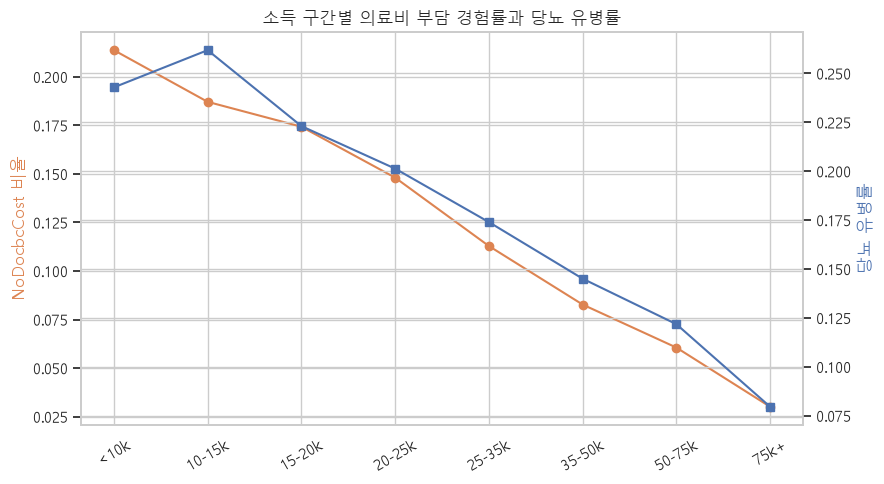

Spearman corr Income vs NoDocbcCost: -0.19673398322516558
Spearman corr Income vs Diabetes_binary: -0.16330469335765088


In [12]:
fig, ax1 = plt.subplots(figsize=(9, 5))
x = np.arange(len(income_order))
ax1.plot(x, income_summary["NoDocbcCost_rate"], marker="o", label="NoDocbcCost 비율", color="#DD8452")
ax1.set_ylabel("NoDocbcCost 비율", color="#DD8452")
ax1.set_xticks(x)
ax1.set_xticklabels(income_order, rotation=30)

ax2 = ax1.twinx()
ax2.plot(x, income_summary["Diabetes_rate"], marker="s", label="당뇨 유병률", color="#4C72B0")
ax2.set_ylabel("당뇨 유병률", color="#4C72B0")

plt.title("소득 구간별 의료비 부담 경험률과 당뇨 유병률")
fig.tight_layout()
plt.show()

# 소득 구간별 상관: NoDocbcCost가 낮은 소득일수록 늘어나는지 스피어만 상관으로 확인
print("Spearman corr Income vs NoDocbcCost:", df_eda["Income"].corr(df_eda["NoDocbcCost"], method="spearman"))
print("Spearman corr Income vs Diabetes_binary:", df_eda["Income"].corr(df_eda["Diabetes_binary"], method="spearman"))

**시사점**: 소득 구간이 낮아질수록 비용장벽 경험률과 당뇨 유병률이 함께, 그리고 거의 단조적으로 증가한다(스피어만 상관 각각 -0.197, -0.163). 최하위 소득군(<10k)은 최상위군(75k+) 대비 비용장벽 7배(21.4% vs 3.0%), 주관적 건강불량 7.7배(48.8% vs 6.3%), 당뇨 유병률 3배(24.3% vs 8.0%) 높다. `Income`이 접근성과 결과 모두를 강하게 설명하는 대표적 교란변수임이 확인되므로, 이후 모델링에서 반드시 통제해야 한다.

## 6. 기초 모델링 - 로지스틱 회귀 (오즈비 비교)

접근성 변수만 넣은 **비보정(unadjusted) 모델**과 `Income`, `Education`, `Age`, `Sex`, `BMI`를 통제한 **보정(adjusted) 모델**을 비교해, 접근성 변수의 오즈비가 교란변수 통제 후에도 유의하게 남는지 확인한다.

타깃: `Diabetes_binary`

In [13]:
def fit_logit_or(formula, data, label):
    model = smf.logit(formula, data=data).fit(disp=0)
    params = model.params
    conf = model.conf_int()
    conf.columns = ["ci_low", "ci_high"]
    or_table = np.exp(pd.concat([params, conf], axis=1))
    or_table.columns = ["odds_ratio", "ci_low", "ci_high"]
    or_table["p_value"] = model.pvalues
    or_table["model"] = label
    return model, or_table

unadj_model, unadj_or = fit_logit_or(
    "Diabetes_binary ~ AnyHealthcare + NoDocbcCost + CholCheck",
    df_eda, "unadjusted"
)
adj_model, adj_or = fit_logit_or(
    "Diabetes_binary ~ AnyHealthcare + NoDocbcCost + CholCheck + Income + Education + Age + Sex + BMI",
    df_eda, "adjusted"
)

compare = pd.concat([
    unadj_or.loc[access_vars],
    adj_or.loc[access_vars]
]).round(4)
compare

,odds_ratio,ci_low,ci_high,p_value,model
AnyHealthcare,1.2882,1.2150,1.3657,0.0,unadjusted
NoDocbcCost,1.4663,1.4110,1.5237,0.0,unadjusted
CholCheck,6.4611,5.6812,7.3481,0.0,unadjusted
AnyHealthcare,1.2271,1.1522,1.3068,0.0,adjusted
NoDocbcCost,1.3666,1.3098,1.4258,0.0,adjusted
CholCheck,5.0983,4.4655,5.8208,0.0,adjusted


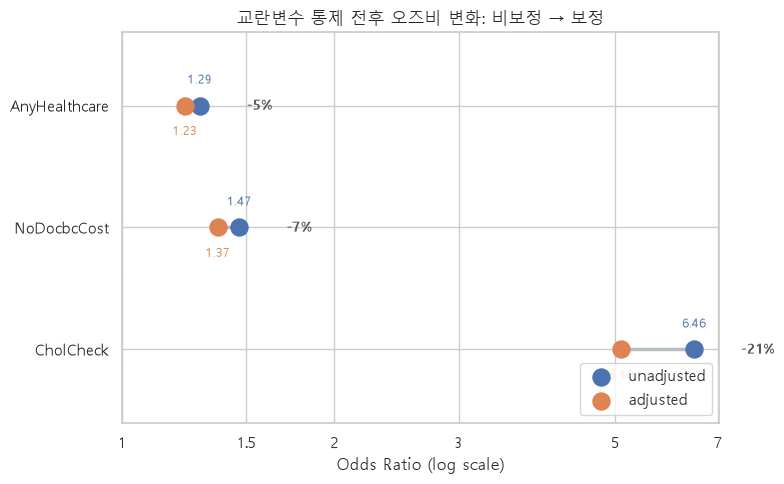

In [14]:
# 비포/애프터 슬로프(덤벨) 그래프: 비보정 -> 보정으로 오즈비가 얼마나, 어느 방향으로 움직였는지 강조
fig, ax = plt.subplots(figsize=(8, 5))
plot_order = ["CholCheck", "NoDocbcCost", "AnyHealthcare"]

for y, v in enumerate(plot_order):
    unadj_val = unadj_or.loc[v, "odds_ratio"]
    adj_val = adj_or.loc[v, "odds_ratio"]
    pct_change = (adj_val - unadj_val) / unadj_val * 100

    ax.plot([unadj_val, adj_val], [y, y], color="#B5BDC0", linewidth=2.5, zorder=1)
    ax.scatter(unadj_val, y, s=150, color="#4C72B0", zorder=3,
               label="unadjusted" if y == 0 else None)
    ax.scatter(adj_val, y, s=150, color="#DD8452", zorder=3,
               label="adjusted" if y == 0 else None)

    ax.annotate(f"{unadj_val:.2f}", (unadj_val, y), textcoords="offset points",
                xytext=(0, 14), ha="center", va="bottom", fontsize=9, color="#4C72B0")
    ax.annotate(f"{adj_val:.2f}", (adj_val, y), textcoords="offset points",
                xytext=(0, -14), ha="center", va="top", fontsize=9, color="#DD8452")
    ax.annotate(f"{pct_change:+.0f}%", (max(unadj_val, adj_val), y), textcoords="offset points",
                xytext=(34, 0), ha="left", va="center", fontsize=10, fontweight="bold", color="#555555")

ax.set_xscale("log")
ax.minorticks_off()
xticks = [1, 1.5, 2, 3, 5, 7]
ax.set_xticks(xticks)
ax.set_xticklabels([str(t) for t in xticks])
ax.axvline(1, color="gray", linestyle="--", zorder=0)
ax.set_yticks(range(len(plot_order)))
ax.set_yticklabels(plot_order)
ax.set_ylim(-0.6, len(plot_order) - 0.4)
ax.set_xlabel("Odds Ratio (log scale)")
ax.set_title("교란변수 통제 전후 오즈비 변화: 비보정 → 보정")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**시사점**: 소득·연령·성별·교육·BMI를 통제해도 세 접근성 변수의 오즈비는 모두 유의하게 남지만 크기는 줄어든다(`AnyHealthcare` 1.29→1.23, `NoDocbcCost` 1.47→1.37, `CholCheck` 6.46→5.10). `CholCheck`의 오즈비가 보정 후에도 5배를 넘는 것은 실제 위험 증가라기보다 "검진을 받아야 당뇨를 진단받는다"는 구조적 이유가 크다고 봐야 한다. 반면 `NoDocbcCost`는 보정 후에도 1.37로 독립적 효과가 뚜렷해, 비용장벽이 소득과 별개로 당뇨 진단·관리에 영향을 준다는 근거가 된다.

### 6.1 모델 가정 점검: 다중공선성(VIF) & 선형성(Box-Tidwell)

로지스틱 회귀 결과를 신뢰하려면 (1) 예측변수 간 다중공선성이 심하지 않은지, (2) 연속형 변수(`BMI`)와 로짓(log-odds) 사이에 선형 관계가 성립하는지 확인해야 한다.

In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = sm.add_constant(df_eda[["AnyHealthcare", "NoDocbcCost", "CholCheck", "Income", "Education", "Age", "Sex", "BMI"]])
vif_df = pd.DataFrame({
    "variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif_df = vif_df[vif_df["variable"] != "const"].reset_index(drop=True)
vif_df

,variable,VIF
0,AnyHealthcare,1.108642
1,NoDocbcCost,1.109160
2,CholCheck,1.022786
3,Income,1.352114
4,Education,1.269509
5,Age,1.071747
6,Sex,1.024262
7,BMI,1.023587


In [16]:
# Box-Tidwell: BMI * ln(BMI) 상호작용항이 유의하면 선형성 가정 위반
df_bt = df_eda.copy()
df_bt["BMI_log_BMI"] = df_bt["BMI"] * np.log(df_bt["BMI"])

bt_model = smf.logit(
    "Diabetes_binary ~ AnyHealthcare + NoDocbcCost + CholCheck + Income + Education + Age + Sex + BMI + BMI_log_BMI",
    data=df_bt
).fit(disp=0)
bt_model.summary2().tables[1].loc[["BMI", "BMI_log_BMI"]]

,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
BMI,1.031006,0.019180,53.75558,0.0,0.993415,1.068597
BMI_log_BMI,-0.205822,0.004181,-49.22305,0.0,-0.214018,-0.197627


**시사점**: VIF가 모두 1.02~1.35로 통상적 기준(5, 보수적으로는 10)을 크게 밑돌아 예측변수 간 다중공선성은 문제가 되지 않는다 — 오즈비 추정치를 안정적으로 신뢰할 수 있다. 다만 Box-Tidwell 검정에서 `BMI_log_BMI` 상호작용항이 강하게 유의하다(계수 -0.206, p<0.001) — `BMI`와 로짓 사이에 완전한 선형 관계가 성립하지 않는다는 뜻이다. 이번 분석은 `BMI`를 통제변수로만 사용했으므로 접근성 변수의 오즈비 해석에는 큰 영향이 없지만, `BMI` 자체를 핵심 설명변수로 다루는 후속 분석에서는 구간화(binning)나 스플라인 등 비선형 처리를 고려해야 한다.

### 6.2 민감도 분석: `CholCheck` 제외 시 오즈비 변화

`CholCheck`의 큰 오즈비(5.10)를 검출편향 — 검진을 받아야 진단이 기록되는 구조 — 으로 의심하고 있다면, 이 변수를 모델에서 아예 빼봤을 때 나머지 접근성 변수들의 오즈비가 얼마나 흔들리는지 확인해 그 의심을 검증해본다.

In [17]:
adj_model_nocc, adj_or_nocc = fit_logit_or(
    "Diabetes_binary ~ AnyHealthcare + NoDocbcCost + Income + Education + Age + Sex + BMI",
    df_eda, "CholCheck 제외"
)

sensitivity = pd.concat([
    adj_or.loc[["AnyHealthcare", "NoDocbcCost"]].assign(model="CholCheck 포함(기존)"),
    adj_or_nocc.loc[["AnyHealthcare", "NoDocbcCost"]]
])[["odds_ratio", "ci_low", "ci_high", "p_value", "model"]].round(4)
sensitivity

,odds_ratio,ci_low,ci_high,p_value,model
AnyHealthcare,1.2271,1.1522,1.3068,0.0,CholCheck 포함(기존)
NoDocbcCost,1.3666,1.3098,1.4258,0.0,CholCheck 포함(기존)
AnyHealthcare,1.3321,1.2514,1.4179,0.0,CholCheck 제외
NoDocbcCost,1.3432,1.2876,1.4012,0.0,CholCheck 제외


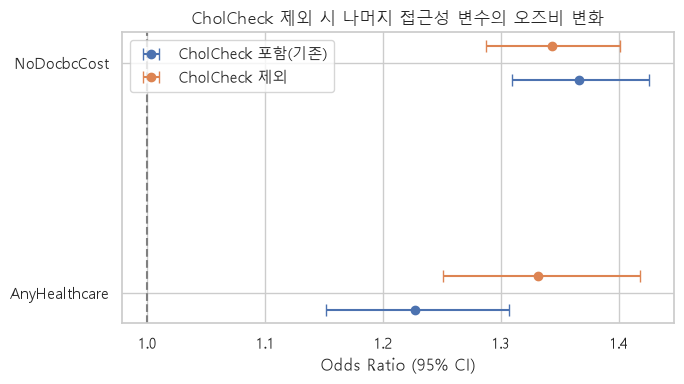

In [18]:
fig, ax = plt.subplots(figsize=(7, 4))
compare_vars = ["AnyHealthcare", "NoDocbcCost"]
scenario_colors = {"CholCheck 포함(기존)": "#4C72B0", "CholCheck 제외": "#DD8452"}
for i, scenario in enumerate(["CholCheck 포함(기존)", "CholCheck 제외"]):
    sub = sensitivity[sensitivity["model"] == scenario].loc[compare_vars]
    y = np.arange(len(compare_vars)) + (i * 0.15)
    ax.errorbar(sub["odds_ratio"], y,
                xerr=[sub["odds_ratio"] - sub["ci_low"], sub["ci_high"] - sub["odds_ratio"]],
                fmt="o", label=scenario, capsize=4, color=scenario_colors[scenario])
ax.axvline(1, color="gray", linestyle="--")
ax.set_yticks(np.arange(len(compare_vars)) + 0.075)
ax.set_yticklabels(compare_vars)
ax.set_xlabel("Odds Ratio (95% CI)")
ax.set_title("CholCheck 제외 시 나머지 접근성 변수의 오즈비 변화")
ax.legend()
plt.tight_layout()
plt.show()

In [19]:
# 왜 변수마다 다르게 반응하는지: CholCheck와의 상관관계로 확인
print("corr(AnyHealthcare, CholCheck):", round(df_eda["AnyHealthcare"].corr(df_eda["CholCheck"]), 4))
print("corr(NoDocbcCost, CholCheck):", round(df_eda["NoDocbcCost"].corr(df_eda["CholCheck"]), 4))
print()
print("AnyHealthcare 비율 (CholCheck 그룹별):")
print(df_eda.groupby("CholCheck")["AnyHealthcare"].mean().round(4))

corr(AnyHealthcare, CholCheck): 0.1176
corr(NoDocbcCost, CholCheck): -0.0583

AnyHealthcare 비율 (CholCheck 그룹별):
CholCheck
0.0    0.8222
1.0    0.9561
Name: AnyHealthcare, dtype: float64


**시사점**: `CholCheck`를 빼자 `NoDocbcCost`의 오즈비는 1.37→1.34로 거의 그대로였지만, `AnyHealthcare`는 오히려 1.23→1.33으로 **더 커졌다**. 이유는 상관관계에 있다 — `AnyHealthcare`와 `CholCheck`의 상관은 0.118로 서로 꽤 연결돼 있는 반면(보험 있는 그룹의 콜레스테롤 검진율 95.6% vs 없는 그룹 82.2%), `NoDocbcCost`와 `CholCheck`의 상관은 -0.058로 거의 무관하다.

즉 `CholCheck`를 모델에서 빼도 검출편향이라는 근본 문제는 사라지지 않고, 서로 얽혀 있던 `AnyHealthcare` 쪽으로 옮겨갈 뿐이다. `Diabetes_binary` 자체가 "진단받은 적 있는지"를 묻는 변수라는 구조적 한계 때문에 생기는 편향이라, 특정 변수 하나를 제거한다고 해결되지 않는다. 반대로 `NoDocbcCost`는 이 민감도 분석에서도 거의 흔들리지 않아, 세 접근성 지표 중 가장 견고한 신호라는 앞선 결론을 다시 한번 뒷받침한다.

### 보조 결과지표: 주관적 건강상태 불량(`PoorGenHlth`)

당뇨 진단 여부 외에, 좀 더 포괄적인 결과지표인 주관적 건강상태(Fair/Poor=1)에 대해서도 동일한 방식으로 비교한다.

In [20]:
unadj_model_g, unadj_or_g = fit_logit_or(
    "PoorGenHlth ~ AnyHealthcare + NoDocbcCost + CholCheck",
    df_eda, "unadjusted"
)
adj_model_g, adj_or_g = fit_logit_or(
    "PoorGenHlth ~ AnyHealthcare + NoDocbcCost + CholCheck + Income + Education + Age + Sex + BMI",
    df_eda, "adjusted"
)

compare_g = pd.concat([
    unadj_or_g.loc[access_vars],
    adj_or_g.loc[access_vars]
]).round(4)
compare_g

,odds_ratio,ci_low,ci_high,p_value,model
AnyHealthcare,0.9594,0.9158,1.0051,0.0806,unadjusted
NoDocbcCost,3.1760,3.0781,3.2771,0.0000,unadjusted
CholCheck,2.0832,1.9467,2.2294,0.0000,unadjusted
AnyHealthcare,1.3210,1.2559,1.3895,0.0000,adjusted
NoDocbcCost,2.4574,2.3727,2.5453,0.0000,adjusted
CholCheck,1.7751,1.6521,1.9073,0.0000,adjusted


**시사점**: 당뇨보다 포괄적인 지표인 주관적 건강상태에서는 접근성 변수의 효과가 당뇨 모델보다 훨씬 크게 나타난다. 특히 `NoDocbcCost`는 비보정 오즈비 3.18, 보정 후에도 2.46으로 매우 강하게 유의해, 비용장벽이 특정 질환 하나보다 **전반적 건강 수준**에 미치는 영향이 크다는 것을 다시 확인시켜 준다. `AnyHealthcare`는 비보정에서는 유의하지 않다가(p=0.08) 보정 후 유의(OR 1.32)해지는데, 이는 보험 미보유가 상대적으로 젊고 건강한 계층에 더 많이 분포해 연령 차이가 원래 효과를 가리고 있었음을 시사한다 — 나이를 통제하자 비로소 드러난 관계다.

## 7. 예측 모델링 및 성능 평가

지금까지는 오즈비로 "접근성과 결과의 연관성 방향·크기"를 봤다. 이번에는 관점을 바꿔 **접근성 변수만으로 당뇨를 얼마나 잘 예측할 수 있는지**를, 전체 21개 변수를 다 쓴 모델과 비교해 확인한다. 두 모델의 성능 차이가 크다면, 접근성은 통계적으로 유의한 연관은 있지만 예측력 있는 신호는 아니라는 뜻이다.

- **Model A (access-only)**: `AnyHealthcare`, `NoDocbcCost`, `CholCheck` 3개 변수만 사용
- **Model B (full)**: `Diabetes_binary`를 제외한 원본 21개 변수 모두 사용
- 클래스 불균형(양성 13.9%)을 고려해 `class_weight="balanced"` 적용, 75/25 stratified train/test split

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix

target = "Diabetes_binary"
access_features = ["AnyHealthcare", "NoDocbcCost", "CholCheck"]
full_features = [c for c in df.columns if c != target]

X_train_a, X_test_a, y_train, y_test = train_test_split(
    df[access_features], df[target], test_size=0.25, stratify=df[target], random_state=42
)
X_train_f, X_test_f, _, _ = train_test_split(
    df[full_features], df[target], test_size=0.25, stratify=df[target], random_state=42
)

def build_pipeline():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
    ])

model_a = build_pipeline().fit(X_train_a, y_train)
model_b = build_pipeline().fit(X_train_f, y_train)

proba_a = model_a.predict_proba(X_test_a)[:, 1]
proba_b = model_b.predict_proba(X_test_f)[:, 1]

auc_a = roc_auc_score(y_test, proba_a)
auc_b = roc_auc_score(y_test, proba_b)
print(f"Model A (access-only) ROC-AUC: {auc_a:.4f}")
print(f"Model B (full features) ROC-AUC: {auc_b:.4f}")

Model A (access-only) ROC-AUC: 0.5317
Model B (full features) ROC-AUC: 0.8219


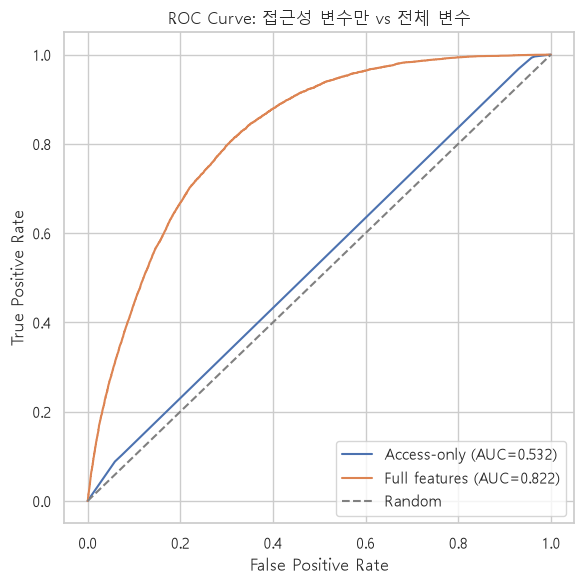

In [22]:
fig, ax = plt.subplots(figsize=(6, 6))
for proba, auc, label in [(proba_a, auc_a, f"Access-only (AUC={auc_a:.3f})"),
                           (proba_b, auc_b, f"Full features (AUC={auc_b:.3f})")]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=label)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve: 접근성 변수만 vs 전체 변수")
ax.legend()
plt.tight_layout()
plt.show()

=== Model A (access-only) classification report (threshold 0.5) ===
              precision    recall  f1-score   support

         0.0       0.93      0.07      0.13     54583
         1.0       0.14      0.97      0.25      8837

    accuracy                           0.19     63420
   macro avg       0.54      0.52      0.19     63420
weighted avg       0.82      0.19      0.15     63420

=== Model B (full features) classification report (threshold 0.5) ===
              precision    recall  f1-score   support

         0.0       0.95      0.73      0.82     54583
         1.0       0.31      0.76      0.44      8837

    accuracy                           0.73     63420
   macro avg       0.63      0.74      0.63     63420
weighted avg       0.86      0.73      0.77     63420



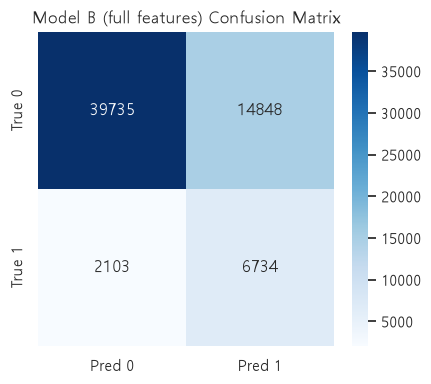

In [23]:
print("=== Model A (access-only) classification report (threshold 0.5) ===")
print(classification_report(y_test, (proba_a >= 0.5).astype(int)))
print("=== Model B (full features) classification report (threshold 0.5) ===")
print(classification_report(y_test, (proba_b >= 0.5).astype(int)))

cm = confusion_matrix(y_test, (proba_b >= 0.5).astype(int))
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"], ax=ax)
ax.set_title("Model B (full features) Confusion Matrix")
plt.tight_layout()
plt.show()

**시사점**: 예측력 차이가 매우 크다. Access-only 모델의 ROC-AUC는 0.532로 사실상 무작위 예측(0.5)에 가깝고, 클래스 불균형을 보정하자 양성을 거의 다 "당뇨"로 예측해버려 정확도가 19%까지 떨어진다(재현율 0.97이지만 정밀도 0.14에 불과). 반면 Full 모델은 ROC-AUC 0.822, 정확도 73%, 양성 클래스 재현율 0.76으로 훨씬 실용적인 성능을 보인다. 이는 앞선 로지스틱 회귀에서 확인한 것처럼 접근성 변수가 **통계적으로 유의한 독립 연관**은 갖고 있지만, 그 자체로는 당뇨를 예측하기엔 턱없이 부족한 신호라는 것을 명확히 보여준다. 실제 예측력은 `GenHlth`, `BMI`, `HighBP`, `Age` 같은 임상·인구통계 지표에서 나오며, **"정책적으로 중요한 변수(접근성)"와 "예측에 유용한 변수"는 다르다**는 것이 이번 분석의 핵심 방법론적 교훈이다.

## 8. 합성데이터 검증: 방법론이 실제로 작동하는가

지금까지 "교란변수를 통제하면 편향이 줄어든다", "`CholCheck`의 큰 오즈비는 검출편향일 것이다"라고 해석해왔다. 하지만 실제 데이터에는 '진짜 정답'이 없어서 이 해석이 맞는지 직접 증명할 수는 없었다. 여기서는 정답(진짜 효과 크기, 진짜 당뇨 여부)을 직접 정해놓은 합성데이터를 만들어, 지금까지 쓴 분석 방법이 그 정답을 실제로 잘 찾아내는지 검증한다.

### 8.1 실험 1 — 교란변수를 통제하면 정말 편향이 줄어드는가

`Income`(교란변수)이 `barrier`(접근성 장벽)와 `diabetes`(결과) 둘 다에 영향을 주도록 20만 명 규모의 가상 데이터를 만든다. `barrier`가 당뇨에 미치는 **"진짜" 오즈비를 1.3으로 미리 정해놓고** 시작한다 — 실제 데이터에서는 알 수 없는 값이지만, 합성데이터에서는 우리가 정한 값이므로 정답을 알고 있다.

In [24]:
rng = np.random.default_rng(42)
n_sim = 200_000

sim_income = rng.uniform(1, 8, n_sim)                       # 소득 (교란변수)
p_barrier = 1 / (1 + np.exp((sim_income - 4.5) * 0.5))      # 소득 높을수록 접근성 장벽 확률 낮음
sim_barrier = rng.binomial(1, p_barrier)

TRUE_OR = 1.3                                                 # 우리가 정해놓은 '진짜' 오즈비
true_log_or = np.log(TRUE_OR)
income_coef = -0.30                                           # 소득 높을수록 당뇨 위험 낮음
logit_p = -1.6 + true_log_or * sim_barrier + income_coef * sim_income
p_diabetes = 1 / (1 + np.exp(-logit_p))
sim_diabetes = rng.binomial(1, p_diabetes)

sim1 = pd.DataFrame({"barrier": sim_barrier, "income": sim_income, "diabetes": sim_diabetes})

m_unadj = smf.logit("diabetes ~ barrier", data=sim1).fit(disp=0)
m_adj = smf.logit("diabetes ~ barrier + income", data=sim1).fit(disp=0)

result1 = pd.DataFrame({
    "odds_ratio": [TRUE_OR, np.exp(m_unadj.params["barrier"]), np.exp(m_adj.params["barrier"])]
}, index=["진짜 값(설계값)", "비보정 추정", "보정 추정(Income 통제)"])
result1.round(3)

,odds_ratio
진짜 값(설계값),1.300
비보정 추정,2.142
보정 추정(Income 통제),1.289


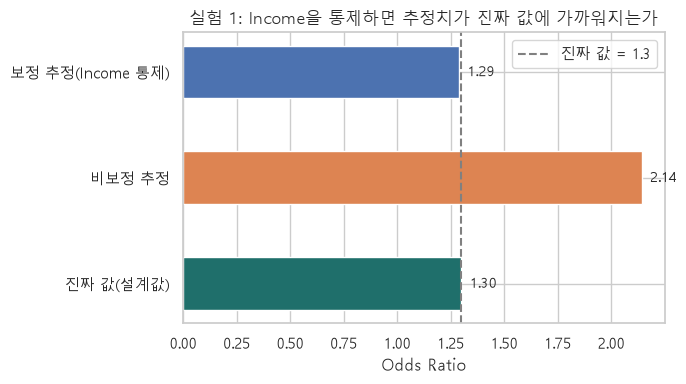

In [25]:
fig, ax = plt.subplots(figsize=(7, 4))
labels1 = list(result1.index)
values1 = result1["odds_ratio"].values
bars1 = ax.barh(labels1, values1, color=["#1F6F6B", "#DD8452", "#4C72B0"], height=0.5)
for b, v in zip(bars1, values1):
    ax.annotate(f"{v:.2f}", (v, b.get_y() + b.get_height() / 2), textcoords="offset points",
                xytext=(6, 0), va="center", fontsize=10)
ax.axvline(TRUE_OR, color="gray", linestyle="--", label=f"진짜 값 = {TRUE_OR}")
ax.set_xlabel("Odds Ratio")
ax.set_title("실험 1: Income을 통제하면 추정치가 진짜 값에 가까워지는가")
ax.legend()
plt.tight_layout()
plt.show()

**시사점**: 우리가 정해놓은 진짜 오즈비는 1.3인데, `Income`을 통제하지 않은 비보정 모델은 2.14로 실제보다 65% 넘게 부풀려서 추정한다. `Income`을 통제한 보정 모델은 1.29로 진짜 값(1.3)에 거의 정확히 들어맞는다. 실제 분석에서 관찰한 "비보정→보정으로 오즈비가 줄어드는 패턴"(예: `NoDocbcCost` 1.47→1.37)이 우연이 아니라, 교란변수를 통제하면 진짜 값에 더 가까워진다는 통계적 원리가 실제로 작동한다는 근거다.

### 8.2 실험 2 — 검출편향은 정말 오즈비를 부풀리는가

이번엔 `screening`(검진, `CholCheck`에 대응)이 **진짜 당뇨 여부와는 완전히 무관하도록**(진짜 인과효과 없음, OR=1) 설계한다. 대신 검진을 받은 사람은 실제 당뇨가 있을 때 95% 확률로 "진단"되고, 안 받은 사람은 40%만 진단되도록 — 즉 검진이 결과를 바꾸는 게 아니라 **발견 확률만 바꾸도록** 설계한다.

In [26]:
rng2 = np.random.default_rng(7)
n_sim2 = 200_000

sim_true_diabetes = rng2.binomial(1, 0.14, n_sim2)
sim_screening = rng2.binomial(1, 0.96, n_sim2)               # 당뇨 위험과 완전 무관하게 무작위 배정
detect_prob = np.where(sim_screening == 1, 0.95, 0.40)        # 검진 여부에 따라 '발견 확률'만 다름
sim_diagnosed = np.where(sim_true_diabetes == 1, rng2.binomial(1, detect_prob), 0)

sim2 = pd.DataFrame({"screening": sim_screening, "true_diabetes": sim_true_diabetes, "diagnosed": sim_diagnosed})

m_true = smf.logit("true_diabetes ~ screening", data=sim2).fit(disp=0)
m_diag = smf.logit("diagnosed ~ screening", data=sim2).fit(disp=0)

result2 = pd.DataFrame({
    "odds_ratio": [np.exp(m_true.params["screening"]), np.exp(m_diag.params["screening"])]
}, index=["진짜 당뇨 기준(관찰 불가)", "진단 여부 기준(우리가 가진 데이터)"])
result2.round(3)

,odds_ratio
진짜 당뇨 기준(관찰 불가),1.021
진단 여부 기준(우리가 가진 데이터),2.693


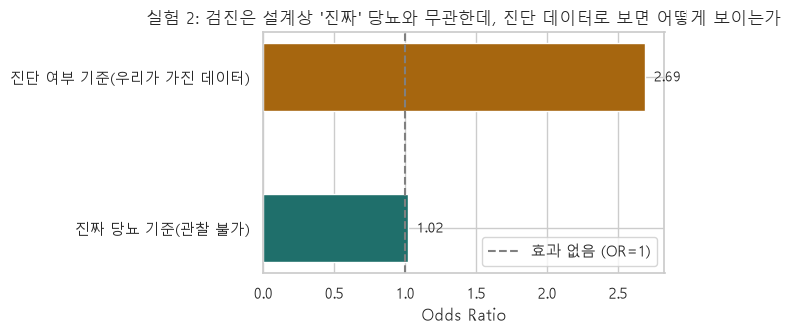

In [27]:
fig, ax = plt.subplots(figsize=(7, 3.5))
labels2 = list(result2.index)
values2 = result2["odds_ratio"].values
bars2 = ax.barh(labels2, values2, color=["#1F6F6B", "#A6660F"], height=0.45)
for b, v in zip(bars2, values2):
    ax.annotate(f"{v:.2f}", (v, b.get_y() + b.get_height() / 2), textcoords="offset points",
                xytext=(6, 0), va="center", fontsize=10)
ax.axvline(1, color="gray", linestyle="--", label="효과 없음 (OR=1)")
ax.set_xlabel("Odds Ratio")
ax.set_title("실험 2: 검진은 설계상 '진짜' 당뇨와 무관한데, 진단 데이터로 보면 어떻게 보이는가")
ax.legend()
plt.tight_layout()
plt.show()

**시사점**: `screening`은 설계상 진짜 당뇨 여부와 완전히 무관하게 무작위로 배정했다(진짜 효과 오즈비=1이어야 정상). 실제로 "진짜 당뇨" 기준으로 보면 오즈비 1.02로 설계한 그대로 거의 정확히 재현된다. 그런데 우리가 실제로 관찰할 수 있는 건 "진단 여부"뿐이고, 검진을 받은 사람은 95%가 발견되는 반면 안 받은 사람은 40%만 발견되도록 설계했더니, 진단 여부 기준 오즈비는 2.69로 크게 부풀려진다. **아무 인과관계가 없어도 검진율 차이만으로 오즈비가 거의 3배 부풀려질 수 있다**는 걸 이 실험이 보여준다. 실제 분석에서 `CholCheck`의 오즈비가 5~6배로 나온 것도 정확히 이 메커니즘 때문일 가능성이 매우 높다는 근거다.

**두 실험이 말해주는 것**: 실험 1은 "왜 교란변수를 통제해야 하는가"를, 실험 2는 "왜 `CholCheck`의 큰 오즈비를 검출편향으로 의심해야 하는가"를 각각 정답을 아는 통제된 환경에서 증명한다. 합성데이터는 우리가 가정한 구조(로지스틱 관계, 특정 확률값)를 그대로 반영할 뿐이라 실제 세계를 완벽히 재현하지는 못하지만, 적어도 **이 분석 전체에서 쓴 통계적 논리 자체는 올바르게 작동한다**는 근거를 확인해준다.

## 9. 종합 결론 및 한계

### 종합 결론

- **교란변수는 상관관계 스크리닝(4절)으로 사전에 선정했다.** `Income`, `Age`, `Education`, `Sex`는 접근성·결과 양쪽과 모두 연관돼 교란변수 조건을 만족했고, `BMI`는 결과와는 강하게 연관되지만 접근성과는 거의 무관해 "교란변수"보다는 "매개변수 가능성이 있는 독립 위험요인"으로 구분해 다뤘다.
- 세 접근성 지표 중 **`NoDocbcCost`(비용장벽)가 가장 신뢰할 수 있고 일관된 신호**다. 소득·연령 등을 통제한 뒤에도 당뇨(OR 1.37)와 주관적 건강불량(OR 2.46) 모두에서 독립적 효과가 유의하게 남는다.
- **`CholCheck`, `AnyHealthcare`의 매우 큰 오즈비는 인과효과가 아니라 검출편향으로 봐야 한다.** 검진·의료 이용이 있어야 질환이 진단·기록되는 구조이므로, "접근성이 질병을 유발한다"가 아니라 "접근성이 있어야 문제가 발견된다"는 방향으로 해석해야 한다.
- **소득에 따른 사회경제적 구배가 뚜렷하다.** 소득이 낮을수록 비용장벽·나쁜 건강상태·당뇨 유병률이 모두 단조적으로 증가하며, `Income`은 접근성과 결과 모두를 설명하는 핵심 교란변수임이 반복적으로 확인됐다.
- **"유의한 연관"과 "예측력"은 다르다.** 접근성 변수 3개만으로 만든 예측 모델의 ROC-AUC는 0.532(사실상 무작위 수준)에 그친 반면, 21개 전체 변수를 쓴 모델은 0.822까지 올라간다 — 접근성은 정책적으로 의미 있는 독립적 연관이지만, 당뇨를 예측하는 데는 임상·인구통계 지표가 훨씬 강한 신호다.
- `BMI`와 로짓 사이 선형성 가정은 위반되지만(Box-Tidwell 유의), 다중공선성(VIF 1.02~1.35)은 문제가 없어 오즈비 추정 자체의 신뢰도는 양호하다.
- **합성데이터 실험으로 방법론 자체를 검증했다.** 진짜 오즈비를 아는 가상 데이터에서, 교란변수를 통제하니 추정치(2.14→1.29)가 진짜 값(1.3)에 정확히 수렴했고, 검진 여부가 진짜 결과와 무관하게 설계됐음에도 발견 확률 차이만으로 오즈비가 1.02→2.69로 부풀려지는 것을 확인했다 — 앞선 해석들이 통계적으로 타당한 논리에 기반했음을 뒷받침한다.

### 한계

- `Diabetes_binary`는 실제 유병 여부가 아니라 **"진단받은 적 있는지"**를 묻는 자가보고 변수라, 접근성이 낮은 집단은 진단 자체를 못 받아 유병률이 과소추정됐을 가능성이 있다(미진단 편향).
- 단면(cross-sectional) 데이터이므로 오즈비는 연관성이지 인과관계를 증명하지 않는다.
- 전체 표본의 9.5%(24,206행)가 완전 중복행이지만, 구간화된 범주형 변수 특성상 데이터 오류로 보기 어려워 삭제하지 않고 유지했다 — 결과 해석 시 참고할 것.

### 정책 시사점

의료 접근성 중에서도 **비용 부담 해소(`NoDocbcCost` 개선)**가 저소득층의 전반적 건강 수준 개선과 가장 강하게 연결되는 지표다. 소득 하위 20~25%(Income 구간 1~2, 연소득 15,000달러 미만) 계층에 의료비 지원을 집중하는 것이 비용 대비 효과가 가장 클 것으로 예상된다. 반면 보험 가입률(`AnyHealthcare`)이나 정기검진율(`CholCheck`) 자체를 결과지표로 사용할 때는 검출편향을 반드시 함께 언급해야 한다.